In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from tqdm import tqdm

from alg.sparse_quad_pfmpc_vel import SparseQuadPFMPCVel
from alg.linear_feedback import LinearFeedback
from models.feedforward import FullyConnected
from dyn.linear_long_vel import LinearLongVel
from utils.iser_leader_traj import accel_decel_step

In [2]:
import os
prefix = os.path.expanduser('~')
fig_save_loc = prefix + '/projects/convoy_notebooks/ctrl/figures'
data_save_loc = prefix + '/projects/convoy_notebooks/ctrl/data'
if not os.path.exists(fig_save_loc):
    os.makedirs(fig_save_loc)
if not os.path.exists(data_save_loc):
    os.makedirs(data_save_loc)
# plt.rcParams["font.family"] = "Times New Roman"

title_size = 9
subtitle_size = 8
axes_size = 8
legend_title_size = 8
legend_font_size = 7
tick_label_size = 7
linewidth = 0.8
linestyle = 'solid'
alphas = [0.7, 0.8, 0.8, 0.8]
alpha = 0.8
scatter_size = 6

# Scale up platoon size

In [3]:
n_trials = 10
H = 50    # planning horizon
N = 101    # N+1 vehicles in platoon, vehicle 0 is virtual leader
dt = 0.1  # timestep
total_time = 25.0  # seconds
total_time += dt * H
d_des = 1.   # desired spacing
da_max = 2.0  # max jerk

# noise properties
dyn_noise = np.array([0.06, 0.06])
sense_noise = np.array([0.045, 0.02])
rng = np.random.default_rng()

# dynamics stuff
v_min, v_max = -100., 200.
d_des = 5.
# v_min, v_max = -0.1, 5.
x_min = np.array([-np.inf, v_min])
x_max = np.array([np.inf, v_max])
u_min = np.array([v_min])
u_max = np.array([v_max])
a_max = 3.
tau_min = 0.2
tau_max = 0.8
taus = [None] + [np.random.uniform(tau_min, tau_max) for _ in range(N)]
dyns = [None] + [LinearLongVel(dt, x_min, x_max, u_min, u_max, tau) for tau in taus[1:]]
n, m, p = dyns[1].n, dyns[1].m, dyns[1].p

# quad pfmpc algorithm
q_vals = [None, 1] + [1 for _ in range(1, N)]
q_p_vals = [None, 1] + [1 for _ in range(1, N)]
r_vals = [None] + [1 for _ in range(N)]
Q = [None] + [q * np.eye(p) for q in q_vals[1:]]
Q_p = [None] + [q_p * np.eye(p) for q_p in q_p_vals[1:]]
R = [None] + [r * np.eye(m) for r in r_vals[1:]]
quad_pfmpc = [None] + [SparseQuadPFMPCVel(Q[i], Q_p[i], R[i], dyns[i], 
                                          v_min, v_max, a_max, H) 
                       for i in range(1, N+1)]

# linear feedback algorithm
k_p = 3
k_v = 6
k_a = 0
lfbk = [None] + [LinearFeedback(k_p, k_v, k_a) for i in range(1, N+1)]

# neural network controller
device = torch.device('cpu')
u_min = torch.tensor([-5.])
u_max = torch.tensor([5.])
hidden_dims = [32, 32]
nn_ctrl = FullyConnected(2, 1, hidden_dims, u_min, u_max, bias=False)
model_file = os.path.expanduser('~') + '/projects/convoy_notebooks/ctrl/models/nn_vel_dyn_controller.pt'
nn_ctrl.load_state_dict(torch.load(model_file, map_location=device))
nn_ctrl.eval();

## Leader trajectory

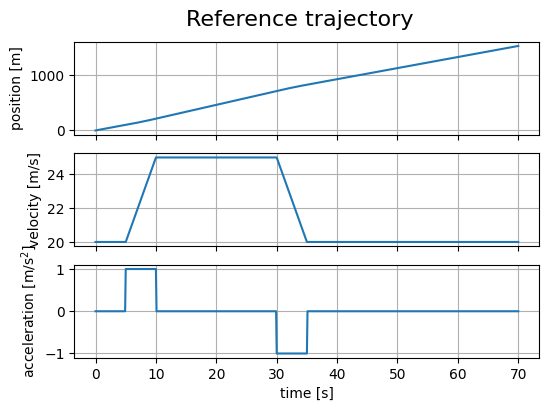

In [4]:
v_low = 20.
v_high = 25.
ref_accel = 1.

init_time = 5.0
time_1 = np.arange(0, init_time + dt, dt)
x_ref_1 = np.zeros((3, len(time_1)))
x_ref_1[1, :] = v_low
for i in range(1, len(time_1)):
    x_ref_1[0, i] = x_ref_1[0, i-1] + dt * x_ref_1[1, i-1]

stag_T = 50.
accel_time = (v_high - v_low) / ref_accel
repeat_accel_start = 0.
repeat_accel_end = repeat_accel_start + accel_time
repeat_decel_start = stag_T / 2.
repeat_decel_end = repeat_decel_start + accel_time
x_ref_2, time_2 = accel_decel_step(
    stag_T, dt, repeat_accel_start, repeat_accel_end,
    repeat_decel_start, repeat_decel_end, v_low, v_high)
x_ref_2[0, :] += x_ref_1[0, -1]
x_ref_2 = np.c_[x_ref_1[:, :-1], x_ref_2]
time_2 += time_1[-1]
time_2 = np.concatenate([time_1[:-1], time_2])

end_time = 20.0
time_3 = np.arange(0, end_time + dt, dt)
x_ref_3 = np.zeros((3, len(time_3)))
x_ref_3[1, :] = v_low
for i in range(1, len(time_3)):
    x_ref_3[0, i] = x_ref_3[0, i-1] + dt * x_ref_3[1, i-1]
x_ref_3[0, :] += x_ref_2[0, -1]
x_ref_3 = np.c_[x_ref_2[:, :-1], x_ref_3]
time_3 += time_2[-1]
time_3 = np.concatenate([time_2[:-1], time_3])

x_ref = x_ref_3
y_ref = x_ref[:2, :]
t_range = time_3

T = len(t_range)
t_range_mpc = t_range[:T-H]

fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
fig.suptitle("Reference trajectory", size=16)
fig.subplots_adjust(top=0.9)

for i in range(x_ref.shape[0]):
    ax[i].plot(t_range[:T-H], x_ref[i, :T-H])
    ax[i].grid()
ax[0].set_ylabel("position [m]")
ax[1].set_ylabel("velocity [m/s]")
ax[2].set_ylabel(r"acceleration [m/s$^2$]")
ax[2].set_xlabel("time [s]");

## Leader reference tracking

### Quadratic PFMPC

In [5]:
x_track = np.zeros((n, T-H))
u_track = np.zeros((m, T-H-1))

# initial condition
x_track[:, 0] = x_ref[:n, 0]

# initialized assumed states, controls, and outputs for first timestep
x_a_track = np.zeros((n, H + 1))
u_a_track = np.zeros((m, H))
x_a_track[:, 0] = x_track[:, 0]
u_a_track[0, :] = x_track[1, 0]
for k in range(H):
    x_a_track[:, k+1] = dyns[1].forward(x_a_track[:, k], u_a_track[:, k])

In [6]:
start_time = time.time()
for k in tqdm(range(T - H - 1)):
    x_0 = x_track[:, k]
    x_a = copy.deepcopy(x_a_track)
    x_pred_a = y_ref[:, k:k+H+1]
    d = 0.

    u_opt, x_opt, prob = quad_pfmpc[1].control(x_0, x_a, x_pred_a, d)
    if prob.status != 'optimal':
        print(f"timestep {k}, problem returned: {prob.status}")
        break

    u_track[:, k] = u_opt[:, 0]
    x_track[:, k+1] = dyns[1].forward(x_0, u_opt[:, 0])

    # update assumed state, control, output
    u_a_track[:, :H-1] = u_opt[:, 1:H]
    u_a_track[:, H-1] = x_pred_a[1, -1]
    x_a_track[:, 0] = x_opt[:, 1]
    for t in range(H):
        x_a_track[:, t+1] = dyns[1].forward(x_a_track[:, t], u_a_track[:, t])
    
end_time = time.time()
avg_time = (end_time - start_time) / (T - H)

100%|██████████| 700/700 [00:02<00:00, 248.44it/s]


In [7]:
print(f"quad pfmpc leader track avg rate: {1 / avg_time} Hz")
print("\nproblem data:")
print(f"    scalar variables: {prob.size_metrics.num_scalar_variables}")
print(f"    scalar eq constraints: {prob.size_metrics.num_scalar_eq_constr}")
print(f"    scalar ineq constraints: {prob.size_metrics.num_scalar_leq_constr}")

quad pfmpc leader track avg rate: 247.78142565749312 Hz

problem data:
    scalar variables: 344
    scalar eq constraints: 296
    scalar ineq constraints: 198


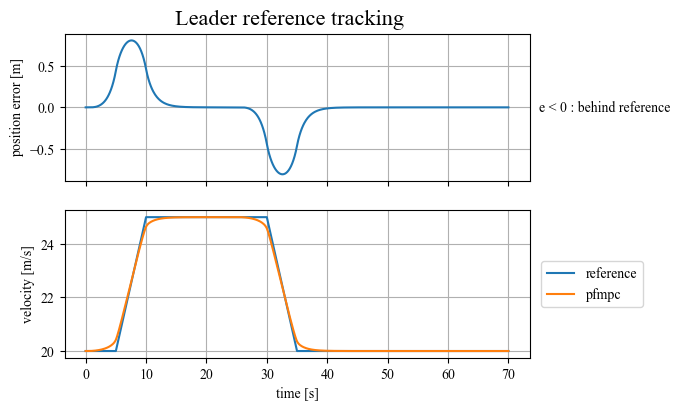

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.suptitle("Leader reference tracking", size=16)
fig.subplots_adjust(top=0.92)

ax[0].plot(t_range[:T-H], x_track[0, :T-H] - x_ref[0, :T-H], label="pf-mpc")
ax[0].text(1.02, 0.5, "e < 0 : behind reference", va='center', 
           transform=ax[0].transAxes)
ax[1].plot(t_range_mpc, x_ref[1, :T-H], label="reference")

ax[1].plot(t_range_mpc, x_track[1, :], label="pfmpc")

ax[0].set_ylabel("position error [m]")
ax[1].set_ylabel("velocity [m/s]")
ax[1].set_xlabel("time [s]")
ax[1].legend(bbox_to_anchor=(1.01, 0.5), loc="center left")

for a in ax.flatten():
    a.grid()

### Linear feedback

In [9]:
x_track = np.zeros((n, T-H))
u_track = np.zeros((m, T-H-1))

# initial condition
x_track[:, 0] = y_ref[:, 0]

In [10]:
start_time = time.time()
for k in tqdm(range(T - H - 1)):
    x_0 = x_track[:, k]
    x_pred = x_ref[:, k]
    d = 0.

    pos_err = x_0[0] - x_pred[0] + d
    vel_err = x_0[1] - x_pred[1]
    accel_err = 0.
    u_opt = x_0[1] + lfbk[1].control(pos_err, vel_err, accel_err) * taus[1]

    u_track[:, k] = u_opt
    x_track[:, k+1] = dyns[1].forward(x_0, np.array([u_opt]))

end_time = time.time()
avg_time = (end_time - start_time) / (T - H)

100%|██████████| 700/700 [00:00<00:00, 181067.70it/s]


In [11]:
print(f"lfbk leader track avg rate: {1 / avg_time} Hz")

lfbk leader track avg rate: 28239.995236037077 Hz


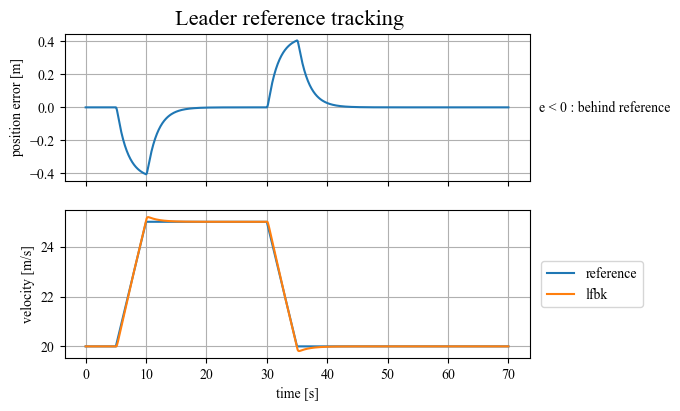

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.suptitle("Leader reference tracking", size=16)
fig.subplots_adjust(top=0.92)

ax[0].plot(t_range[:T-H], x_track[0, :T-H] - x_ref[0, :T-H], label="pf-mpc")
ax[0].text(1.02, 0.5, "e < 0 : behind reference", va='center', 
           transform=ax[0].transAxes)
ax[1].plot(t_range_mpc, x_ref[1, :T-H], label="reference")

# ax[0].plot(t_range_mpc, x_track[0, :], label="pf-mpc")
ax[1].plot(t_range_mpc, x_track[1, :], label="lfbk")

ax[0].set_ylabel("position error [m]")
ax[1].set_ylabel("velocity [m/s]")
ax[1].set_xlabel("time [s]")
ax[1].legend(bbox_to_anchor=(1.01, 0.5), loc="center left")

for a in ax.flatten():
    a.grid()

### Neural network controller

In [13]:
x_track = np.zeros((n, T-H))
u_track = np.zeros((m, T-H-1))

# initial condition
x_track[:, 0] = y_ref[:, 0]

In [14]:
start_time = time.time()
for k in tqdm(range(T - H - 1)):
    x_0 = x_track[:, k]
    x_pred = x_ref[:, k]
    d = 0.

    pos_err = -(x_0[0] - x_pred[0] + d)
    vel_err = -(x_0[1] - x_pred[1])
    err = [[pos_err, vel_err]]

    nn_input = torch.from_numpy(np.array(err)).float()

    nn_action = nn_ctrl(nn_input).detach().squeeze().numpy()
    u_opt = x_0[1] + nn_action * taus[1]

    u_track[:, k] = u_opt
    x_track[:, k+1] = dyns[1].forward(x_0, np.array([u_opt]))

end_time = time.time()
avg_time = (end_time - start_time) / (T - H)

100%|██████████| 700/700 [00:00<00:00, 13969.31it/s]


In [15]:
print(f"nn leader track avg rate: {1 / avg_time} Hz")

nn leader track avg rate: 12407.560077478489 Hz


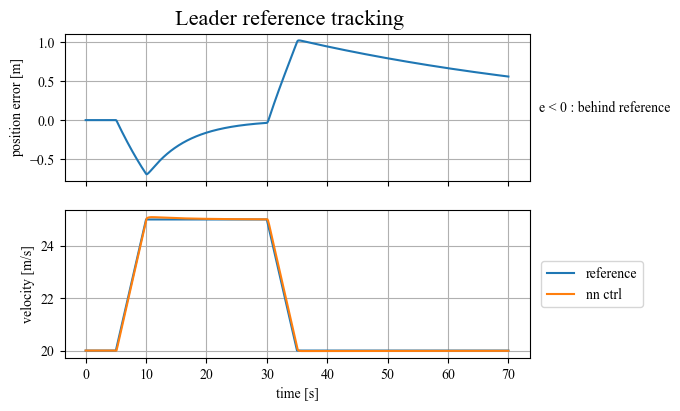

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.suptitle("Leader reference tracking", size=16)
fig.subplots_adjust(top=0.92)

ax[0].plot(t_range[:T-H], x_track[0, :T-H] - x_ref[0, :T-H], label="pf-mpc")
ax[0].text(1.02, 0.5, "e < 0 : behind reference", va='center', 
           transform=ax[0].transAxes)
ax[1].plot(t_range_mpc, x_ref[1, :T-H], label="reference")

# ax[0].plot(t_range_mpc, x_track[0, :], label="pf-mpc")
ax[1].plot(t_range_mpc, x_track[1, :], label="nn ctrl")

ax[0].set_ylabel("position error [m]")
ax[1].set_ylabel("velocity [m/s]")
ax[1].set_xlabel("time [s]")
ax[1].legend(bbox_to_anchor=(1.01, 0.5), loc="center left")

for a in ax.flatten():
    a.grid()

## Platoon experiment - evaluate RMSE performance as platoon size increases

In [17]:
def init_quad_pfmpc(n, m, N, T, H, dyns, x_ref: np.ndarray, d_des):
    x_quad_pfmpc = np.zeros((N+1, T-H, n))
    u_quad_pfmpc = np.zeros((N+1, T-H-1, m))

    # zeroth vehicle is virtual leader
    x_quad_pfmpc[0] = x_ref.T[:T-H, :n]
    u_quad_pfmpc[0, :T-H-1, 0] = x_ref.T[:T-H-1, 1]

    # initial condition: start in correct place with desired spacing, velocity, and 
    # acceleration
    for i in range(1, N + 1):
        d = 0 if i == 1 else d_des
        x_quad_pfmpc[i, 0] = np.array([-(i-1)*d, x_quad_pfmpc[0, 0, 1]])

    # initialize assumed states, controls, and output for first timestep
    x_a_quad_pfmpc = np.zeros((N+1, H+1, n))
    x_a_quad_pfmpc[0] = x_quad_pfmpc[0, :H+1, :]
    u_a_quad_pfmpc = np.zeros((N+1, H, m))
    u_a_quad_pfmpc[0] = u_quad_pfmpc[0, :H, :]
    for i in range(1, N + 1):
        x_a_quad_pfmpc[i, 0] = x_quad_pfmpc[i, 0]
        u_a_quad_pfmpc[i, :] = x_quad_pfmpc[i, 0, 1]

    for i in range(1, N+1):
        for k in range(H):
            x_a_quad_pfmpc[i, k+1] = dyns[i].forward(x_a_quad_pfmpc[i, k], 
                                                     u_a_quad_pfmpc[i, k])

    return x_quad_pfmpc, u_quad_pfmpc, x_a_quad_pfmpc, u_a_quad_pfmpc

In [18]:
def init_lfbk(n, m, N, T, H, d_des):
    x_lfbk = np.zeros((N+1, T-H, n))
    u_lfbk = np.zeros((N+1, T-H-1, m))

    # zeroth vehicle is virtual leader
    x_lfbk[0] = x_ref.T[:T-H, :n]
    u_lfbk[0, :T-H-1, 0] = x_ref.T[:T-H-1, 1]

    # initial condition: start in correct place with desired spacing, velocity, and 
    # acceleration
    for i in range(1, N + 1):
        d = 0 if i == 1 else d_des
        x_lfbk[i, 0] = np.array([-(i-1)*d, x_lfbk[0, 0, 1]])
    
    return x_lfbk, u_lfbk

In [19]:
def init_nn_ctrl(n, m, N, T, H, d_des):
    x_nn = np.zeros((N+1, T-H, n))
    u_nn = np.zeros((N+1, T-H-1, m))

    # zeroth vehicle is virtual leader
    x_nn[0] = x_ref.T[:T-H, :n]
    u_nn[0, :T-H-1, 0] = x_ref.T[:T-H-1, 1]

    # initial condition: start in correct place with desired spacing, velocity, and 
    # acceleration
    for i in range(1, N + 1):
        d = 0 if i == 1 else d_des
        x_nn[i, 0] = np.array([-(i-1)*d, x_nn[0, 0, 1]])
    
    return x_nn, u_nn

In [20]:
# list of lists to hold vel rms errors, each inner list corresponds to a vehicle, 
# each element of inner list is vehicle's errors during that trial
quad_pfmpc_dist_errors = np.zeros((n_trials, N+1, T-H))
quad_pfmpc_vel_errors = np.zeros((n_trials, N+1, T-H))
lfbk_dist_errors = np.zeros((n_trials, N+1, T-H))
lfbk_vel_errors = np.zeros((n_trials, N+1, T-H))
nn_dist_errors = np.zeros((n_trials, N+1, T-H))
nn_vel_errors = np.zeros((n_trials, N+1, T-H))

# also store trajectory data from trials
quad_pfmpc_x_trajs = np.zeros((n_trials, N+1, T-H, n))
quad_pfmpc_u_trajs = np.zeros((n_trials, N+1, T-H-1, m))
lfbk_x_trajs = np.zeros((n_trials, N+1, T-H, n))
lfbk_u_trajs = np.zeros((n_trials, N+1, T-H-1, m))
nn_x_trajs = np.zeros((n_trials, N+1, T-H, n))
nn_u_trajs = np.zeros((n_trials, N+1, T-H-1, m))

In [21]:
no_soln = False
for j in tqdm(range(n_trials)):

    x_quad_pfmpc, u_quad_pfmpc, x_a_quad_pfmpc, u_a_quad_pfmpc = \
        init_quad_pfmpc(n, m, N, T, H, dyns, x_ref, d_des)
    x_a_quad_pfmpc_prev = copy.deepcopy(x_a_quad_pfmpc)
    u_a_quad_pfmpc_prev = copy.deepcopy(u_a_quad_pfmpc)

    x_lfbk, u_lfbk = init_lfbk(n, m, N, T, H, d_des)

    x_nn, u_nn = init_nn_ctrl(n, m, N, T, H, d_des)

    for k in tqdm(range(T - H - 1)):
        for i in range(1, N+1):
            v = rng.normal(0, dyn_noise)
            w = rng.normal(0, sense_noise)

            # quad pfmpc
            x_0 = x_quad_pfmpc[i, k] + v
            x_a = x_a_quad_pfmpc_prev[i].copy()
            x_pred_a = x_a_quad_pfmpc_prev[i-1].copy()
            if i > 1:
                dist = x_quad_pfmpc[i-1, k, 0] - x_quad_pfmpc[i, k, 0] + w[0]
                x_pred_a[:, 0] -= x_pred_a[0, 0]
                x_pred_a[:, 0] += x_0[0] + dist
            d = 0 if i == 1 else d_des

            u_opt, x_opt, prob = quad_pfmpc[i].control(x_0, x_a.T, x_pred_a.T, d)
            if prob.status != 'optimal':
                print(f"timestep {k}, vehicle {i}, problem returned: {prob.status}")
                no_soln = True
            
            u_quad_pfmpc[i, k] = u_opt[:, 0]
            x_quad_pfmpc[i, k+1] = dyns[i].forward(x_quad_pfmpc[i, k], u_opt[:, 0]) + v
            
            u_a_quad_pfmpc[i, :H-1] = u_opt[:, 1:H].T
            u_a_quad_pfmpc[i, H-1, 0] = x_opt[1, H]
            x_a_quad_pfmpc[i, 0] = x_opt[:, 1]
            for t in range(H):
                x_a_quad_pfmpc[i, t+1] = dyns[i].forward(x_a_quad_pfmpc[i, t],
                                                         u_a_quad_pfmpc[i, t])

            # lfbk
            x_0 = x_lfbk[i, k]
            d = 0 if i == 1 else d_des
            pos_err = x_lfbk[i, k, 0] - x_lfbk[i-1, k, 0] + d + w[0]
            vel_err = x_lfbk[i, k, 1] - x_lfbk[i-1, k, 1] + w[1]
            u_opt = x_0[1] + lfbk[i].control(pos_err, vel_err, 0.) * taus[i]

            u_lfbk[i, k] = u_opt
            x_lfbk[i, k+1] = dyns[i].forward(x_lfbk[i, k], np.array([u_opt])) + v

            # nn ctrl
            x_0 = x_nn[i, k]
            d = 0 if i == 1 else d_des
            pos_err = -(x_nn[i, k, 0] - x_nn[i-1, k, 0] + d + w[0])
            vel_err = -(x_nn[i, k, 1] - x_nn[i-1, k, 1] + w[1])
            err = [[pos_err, vel_err]]

            nn_input = torch.tensor(err).float()
            nn_action = nn_ctrl(nn_input).detach().squeeze().numpy()
            u_opt = x_0[1] + nn_action * taus[i]

            u_nn[i, k] = u_opt
            x_nn[i, k+1] = dyns[i].forward(x_nn[i, k], np.array([u_opt])) + v
        
        if no_soln:
            break

        x_a_quad_pfmpc[0] = x_ref[:n, k+1:k+H+2].T
        u_a_quad_pfmpc[0] = x_ref[1, k+1:k+H+1].reshape(-1, 1)
        x_a_quad_pfmpc_prev = copy.deepcopy(x_a_quad_pfmpc)
        u_a_quad_pfmpc_prev = copy.deepcopy(u_a_quad_pfmpc)

    quad_pfmpc_x_trajs[j] = x_quad_pfmpc.copy()
    quad_pfmpc_u_trajs[j] = u_quad_pfmpc.copy()
    lfbk_x_trajs[j] = x_lfbk.copy()
    lfbk_u_trajs[j] = u_lfbk.copy()
    nn_x_trajs[j] = x_nn.copy()
    nn_u_trajs[j] = u_nn.copy()

    for i in range(1, N + 1):
        d = 0 if i == 1 else d_des
        quad_pfmpc_dist_errors[j, i] = x_quad_pfmpc[i, :, 0] - x_quad_pfmpc[i-1, :, 0] + d
        quad_pfmpc_vel_errors[j, i] = x_quad_pfmpc[i, :, 1] - x_quad_pfmpc[i-1, :, 1]
        lfbk_dist_errors[j, i] = x_lfbk[i, :, 0] - x_lfbk[i-1, :, 0] + d
        lfbk_vel_errors[j, i] = x_lfbk[i, :, 1] - x_lfbk[i-1, :, 1]
        nn_dist_errors[j, i] = x_nn[i, :, 0] - x_nn[i-1, :, 0] + d
        nn_vel_errors[j, i] = x_nn[i, :, 1] - x_nn[i-1, :, 1]

100%|██████████| 10/10 [1:24:35<00:00, 507.59s/it]


In [34]:
np.save(data_save_loc + '/quad_pfmpc_x_trajs.npy', quad_pfmpc_x_trajs)
np.save(data_save_loc + '/quad_pfmpc_u_trajs.npy', quad_pfmpc_u_trajs)
np.save(data_save_loc + '/quad_pfmpc_dist_errors.npy', quad_pfmpc_dist_errors)
np.save(data_save_loc + '/quad_pfmpc_vel_errors.npy', quad_pfmpc_vel_errors)
np.save(data_save_loc + '/lfbk_x_trajs.npy', lfbk_x_trajs)
np.save(data_save_loc + '/lfbk_u_trajs.npy', lfbk_u_trajs)
np.save(data_save_loc + '/lfbk_dist_errors.npy', lfbk_dist_errors)
np.save(data_save_loc + '/lfbk_vel_errors.npy', lfbk_vel_errors)
np.save(data_save_loc + '/nn_x_trajs.npy', nn_x_trajs)
np.save(data_save_loc + '/nn_u_trajs.npy', nn_u_trajs)
np.save(data_save_loc + '/nn_dist_errors.npy', nn_dist_errors)
np.save(data_save_loc + '/nn_vel_errors.npy', nn_vel_errors)

In [10]:
quad_pfmpc_x_trajs = np.load(data_save_loc + '/quad_pfmpc_x_trajs.npy')
quad_pfmpc_u_trajs = np.load(data_save_loc + '/quad_pfmpc_u_trajs.npy')
quad_pfmpc_dist_errors = np.load(data_save_loc + '/quad_pfmpc_dist_errors.npy')
quad_pfmpc_vel_errors = np.load(data_save_loc + '/quad_pfmpc_vel_errors.npy')
lfbk_x_trajs = np.load(data_save_loc + '/lfbk_x_trajs.npy')
lfbk_u_trajs = np.load(data_save_loc + '/lfbk_u_trajs.npy')
lfbk_dist_errors = np.load(data_save_loc + '/lfbk_dist_errors.npy')
lfbk_vel_errors = np.load(data_save_loc + '/lfbk_vel_errors.npy')
nn_x_trajs = np.load(data_save_loc + '/nn_x_trajs.npy')
nn_u_trajs = np.load(data_save_loc + '/nn_u_trajs.npy')
nn_dist_errors = np.load(data_save_loc + '/nn_dist_errors.npy')
nn_vel_errors = np.load(data_save_loc + '/nn_vel_errors.npy')

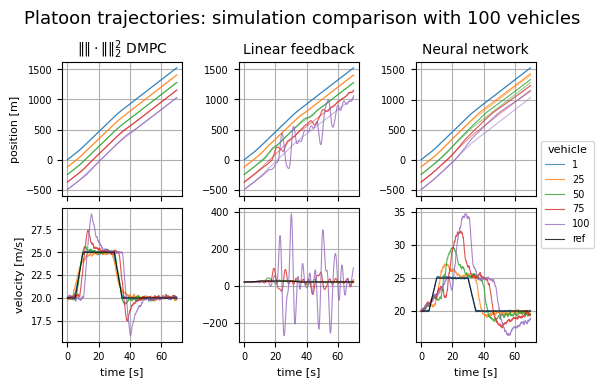

In [11]:
# let's look at plots from one of the trials
plot_i = 0

fig, ax = plt.subplots(2, 3, sharex='col', figsize=(6.0, 4.0))
fig.suptitle(f'Platoon trajectories: simulation comparison with {N-1} vehicles', fontsize=title_size+4)
fig.subplots_adjust(.1, .15, .89, .85, .47, .09)
ax[0,0].set_title(rf'$\|\|\cdot\|\|_2^2$ DMPC', fontsize=subtitle_size+2)
ax[0,1].set_title("Linear feedback", fontsize=subtitle_size+2)
ax[0,2].set_title("Neural network", fontsize=subtitle_size+2)

# veh_inds = range(1, N+1, 2)
veh_inds = [1, 25, 50, 75, 100]
for k, i in enumerate(veh_inds):
    ax[0,0].plot(t_range_mpc, quad_pfmpc_x_trajs[plot_i, i, :, 0], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)
    ax[0,1].plot(t_range_mpc, lfbk_x_trajs[plot_i, i, :, 0], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)
    ax[0,2].plot(t_range_mpc, nn_x_trajs[plot_i, i, :, 0], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)

    ax[1,0].plot(t_range_mpc, quad_pfmpc_x_trajs[plot_i, i, :, 1], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)
    ax[1,1].plot(t_range_mpc, lfbk_x_trajs[plot_i, i, :, 1], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)
    ax[1,2].plot(t_range_mpc, nn_x_trajs[plot_i, i, :, 1], label=f'{i}', 
                 color=f"C{k}", linewidth=linewidth, alpha=alpha)
    for j in range(3):
        ax[0,j].plot(t_range_mpc, quad_pfmpc_x_trajs[0, 0, :, 0] - (i-1)*d_des, color=f"C{k}", 
                     alpha=0.5, linewidth=linewidth)
for j in range(3):
    ax[1,j].plot(t_range_mpc, quad_pfmpc_x_trajs[0, 0, :, 1], color="k", label='ref', 
                 linewidth=linewidth, alpha=alpha)

ax[0,0].set_ylabel('position [m]', fontsize=axes_size)
ax[1,0].set_ylabel('velocity [m/s]', fontsize=axes_size)
ax[1,0].set_xlabel('time [s]', fontsize=axes_size)
ax[1,1].set_xlabel('time [s]', fontsize=axes_size)
ax[1,2].set_xlabel('time [s]', fontsize=axes_size)

for a in ax.flat:
    a.grid()
    a.tick_params(axis='both', labelsize=tick_label_size)
ax[1,2].legend(bbox_to_anchor=(1.0, 1.1), loc="center left", title="vehicle",
               fontsize=legend_font_size, title_fontsize=legend_title_size);

traj_save_loc = fig_save_loc + '/iros_sim_traj.pdf'
fig.savefig(traj_save_loc, bbox_inches='tight')

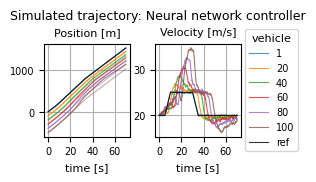

In [12]:
# let's look at plots from one of the trials
plot_i = 0

fig, ax = plt.subplots(1, 2, sharex='col', figsize=(2.85, 1.5))
fig.suptitle(f'Simulated trajectory: Neural network controller', 
             fontsize=title_size, x=0.45)
ax[0].set_title('Position [m]', fontsize=subtitle_size)
ax[1].set_title('Velocity [m/s]', fontsize=subtitle_size)
fig.subplots_adjust(.05, .13, .74, .75, .3, .2)

veh_inds = [1, 20, 40, 60, 80, 100]
for k, i in enumerate(veh_inds):
    ax[0].plot(t_range_mpc, nn_x_trajs[plot_i, i, :, 0], label=f'{i}', 
               linewidth=linewidth, alpha=alpha)
    ax[0].plot(t_range_mpc, nn_x_trajs[plot_i, 0, :, 0] - (i-1)*d_des, color=f"C{k}", 
               alpha=0.5, linewidth=linewidth)
    ax[1].plot(t_range_mpc, nn_x_trajs[plot_i, i, :, 1], label=f'{i}', 
               color=f"C{k}", linewidth=linewidth, alpha=alpha)
ax[0].plot(t_range_mpc, nn_x_trajs[plot_i, 0, :, 0], color="k", label='ref', 
                linewidth=linewidth, alpha=alpha)
ax[1].plot(t_range_mpc, nn_x_trajs[plot_i, 0, :, 1], color="k", label='ref', 
                linewidth=linewidth, alpha=alpha)

# ax[0].set_ylabel('position [m]', fontsize=axes_size)
# ax[1].set_ylabel('velocity [m/s]', fontsize=axes_size)
ax[0].set_xlabel('time [s]', fontsize=axes_size)
ax[1].set_xlabel('time [s]', fontsize=axes_size)

for a in ax.flat:
    a.grid()
    a.tick_params(axis='both', labelsize=tick_label_size)
ax[1].legend(bbox_to_anchor=(0.99, 0.5), loc="center left", title="vehicle",
             fontsize=legend_font_size, title_fontsize=legend_title_size);
for a in ax:
    a.set_xticks([0, 20, 40, 60])

traj_save_loc = fig_save_loc + '/iros_sim_nn_trajectory.pdf'
fig.savefig(traj_save_loc, bbox_inches='tight')

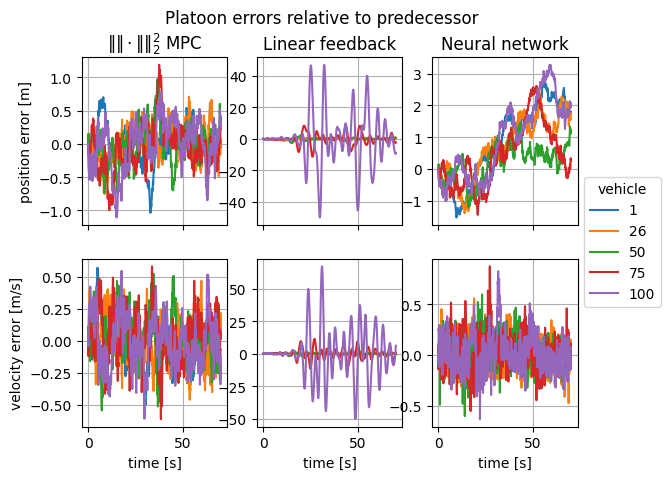

In [13]:
plot_i = 0

fig, ax = plt.subplots(2, 3, sharex='col')
fig.suptitle('Platoon errors relative to predecessor')
ax[0,0].set_title(rf'$\|\|\cdot\|\|_2^2$ MPC')
ax[0,1].set_title("Linear feedback")
ax[0,2].set_title("Neural network")

for i in np.linspace(1, N-1, min(N, 5)).round().astype(int):
    ax[0,0].plot(t_range_mpc, quad_pfmpc_dist_errors[plot_i, i], label=f'{i}')
    ax[0,1].plot(t_range_mpc, lfbk_dist_errors[plot_i, i], label=f'{i}')
    ax[0,2].plot(t_range_mpc, nn_dist_errors[plot_i, i], label=f'{i}')

    ax[1,0].plot(t_range_mpc, quad_pfmpc_vel_errors[plot_i, i], label=f'{i}')
    ax[1,1].plot(t_range_mpc, lfbk_vel_errors[plot_i, i], label=f'{i}')
    ax[1,2].plot(t_range_mpc, nn_vel_errors[plot_i, i], label=f'{i}')

ax[0,0].set_ylabel('position error [m]')
ax[1,0].set_ylabel('velocity error [m/s]')
ax[1,0].set_xlabel('time [s]')
ax[1,1].set_xlabel('time [s]')
ax[1,2].set_xlabel('time [s]')

for a in ax.flat:
    a.grid()
    a.tick_params(axis='both')
ax[0,2].legend(bbox_to_anchor=(1.0, -0.1), loc="center left", title="vehicle");

In [14]:
# get RMS mean/stds for each vehicle
quad_pfmpc_dist_rms_means = []
quad_pfmpc_dist_rms_stds = []
quad_pfmpc_vel_rms_means = []
quad_pfmpc_vel_rms_stds = []
lfbk_dist_rms_means = []
lfbk_dist_rms_stds = []
lfbk_vel_rms_means = []
lfbk_vel_rms_stds = []
nn_dist_rms_means = []
nn_dist_rms_stds = []
nn_vel_rms_means = []
nn_vel_rms_stds = []

for i in range(2, N+1):
    quad_means = [np.sqrt(np.mean(np.square(quad_pfmpc_dist_errors[j, i]))) for j in range(n_trials)]
    quad_pfmpc_dist_rms_means.append(np.mean(quad_means))
    quad_pfmpc_dist_rms_stds.append(np.std(quad_means))
    quad_means = [np.sqrt(np.mean(np.square(quad_pfmpc_vel_errors[j, i]))) for j in range(n_trials)]
    quad_pfmpc_vel_rms_means.append(np.mean(quad_means))
    quad_pfmpc_vel_rms_stds.append(np.std(quad_means))

    lfbk_means = [np.sqrt(np.mean(np.square(lfbk_dist_errors[j, i]))) for j in range(n_trials)]
    lfbk_dist_rms_means.append(np.mean(lfbk_means))
    lfbk_dist_rms_stds.append(np.std(lfbk_means))
    lfbk_means = [np.sqrt(np.mean(np.square(lfbk_vel_errors[j, i]))) for j in range(n_trials)]
    lfbk_vel_rms_means.append(np.mean(lfbk_means))
    lfbk_vel_rms_stds.append(np.std(lfbk_means))

    nn_means = [np.sqrt(np.mean(np.square(nn_dist_errors[j, i]))) for j in range(n_trials)]
    nn_dist_rms_means.append(np.mean(nn_means))
    nn_dist_rms_stds.append(np.std(nn_means))
    nn_means = [np.sqrt(np.mean(np.square(nn_vel_errors[j, i]))) for j in range(n_trials)]
    nn_vel_rms_means.append(np.mean(nn_means))
    nn_vel_rms_stds.append(np.std(nn_means))

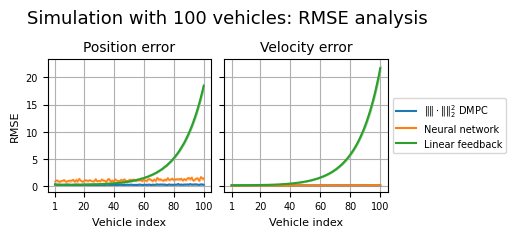

In [16]:
veh_inds = range(1, N)
fig, ax = plt.subplots(1, 2, sharey='row', figsize=(4.0, 2.5))
fig.subplots_adjust(.05, .25, .9, .78, .08, .1)
fig.suptitle(f'Simulation with {N-1} vehicles: RMSE analysis', 
             fontsize=title_size + 4, x=0.5)
ax[0].set_title("Position error", fontsize=subtitle_size + 2)
ax[1].set_title("Velocity error", fontsize=subtitle_size + 2)

quad_pfmpc_dist_err = quad_pfmpc_dist_rms_stds/np.sqrt(n_trials)
quad_pfmpc_vel_err = quad_pfmpc_vel_rms_stds/np.sqrt(n_trials)
ax[0].plot(veh_inds, quad_pfmpc_dist_rms_means, color="C{}".format(0), 
           label=r'$\|\|\cdot\|\|_2^2$ DMPC')
ax[0].fill_between(veh_inds, 
                   quad_pfmpc_dist_rms_means - quad_pfmpc_dist_err,
                   quad_pfmpc_dist_rms_means + quad_pfmpc_dist_err,
                   alpha=0.4, color="C{}".format(0))
ax[1].plot(veh_inds, quad_pfmpc_vel_rms_means, color="C{}".format(0), 
           label=r'$\|\|\cdot\|\|_2^2$ DMPC')
ax[1].fill_between(veh_inds, 
                   quad_pfmpc_vel_rms_means - quad_pfmpc_vel_err,
                   quad_pfmpc_vel_rms_means + quad_pfmpc_vel_err, 
                   alpha=0.4, color="C{}".format(0))

nn_dist_err = nn_dist_rms_stds/np.sqrt(n_trials)
nn_vel_err = nn_vel_rms_stds/np.sqrt(n_trials)
ax[0].plot(veh_inds, nn_dist_rms_means, color="C{}".format(1), 
           label='Neural network', linewidth=1)
ax[0].fill_between(veh_inds, 
                   nn_dist_rms_means - nn_dist_err,
                   nn_dist_rms_means + nn_dist_err, 
                   alpha=0.4, color="C{}".format(1))
ax[1].plot(veh_inds, nn_vel_rms_means, color="C{}".format(1), 
           label='Neural network')
ax[1].fill_between(veh_inds, 
                   nn_vel_rms_means - nn_vel_err,
                   nn_vel_rms_means + nn_vel_err, 
                   alpha=0.4, color="C{}".format(1))


lfbk_dist_err = lfbk_dist_rms_stds/np.sqrt(n_trials)
lfbk_vel_err = lfbk_vel_rms_stds/np.sqrt(n_trials)
ax[0].plot(veh_inds, lfbk_dist_rms_means, color="C{}".format(2), 
           label='Linear feedback')
ax[0].fill_between(veh_inds, 
                   lfbk_dist_rms_means - lfbk_dist_err,
                   lfbk_dist_rms_means + lfbk_dist_err, 
                   alpha=0.4, color="C{}".format(2))
ax[1].plot(veh_inds, lfbk_vel_rms_means, color="C{}".format(2), 
           label='Linear feedback')
ax[1].fill_between(veh_inds, 
                   lfbk_vel_rms_means - lfbk_vel_err,
                   lfbk_vel_rms_means + lfbk_vel_err,
                   alpha=0.4, color="C{}".format(2))

# ax[1].legend(bbox_to_anchor=(1.0, 0.5), loc='center left', fontsize=legend_font_size, 
#              title='Method', title_fontsize=legend_title_size)

ax[0].set_ylabel('RMSE', fontsize=axes_size)
ax[0].set_xlabel('Vehicle index', fontsize=axes_size)
ax[1].set_xlabel('Vehicle index', fontsize=axes_size)

for a in ax:
    a.grid()
    a.set_xticks([1, 20, 40, 60, 80, 100])
    a.tick_params(axis='both', labelsize=tick_label_size)

ax[1].legend(bbox_to_anchor=(1.0, 0.5), loc='center left', fontsize=legend_font_size)

rms_save_loc = fig_save_loc + '/iros_sim_rms_fig.pdf'
fig.savefig(rms_save_loc, bbox_inches='tight')

In [11]:
# zoomed in version

ax[0].set_ylabel('RMSE', fontsize=axes_size)
ax[0].set_xlabel('Vehicle index', fontsize=axes_size)
ax[1].set_xlabel('Vehicle index', fontsize=axes_size)
ax[0].set_ylim([0, 1.8])
ax[0].set_yticks([0, .5, 1., 1.5])

for a in ax:
    a.set_xticks([1, 20, 40, 60, 80, 100])
    a.tick_params(axis='both', labelsize=tick_label_size)

rms_save_loc_zoomed = fig_save_loc + '/iros_sim_rms_zoomed_fig.pdf'
fig.savefig(rms_save_loc_zoomed, bbox_inches='tight')

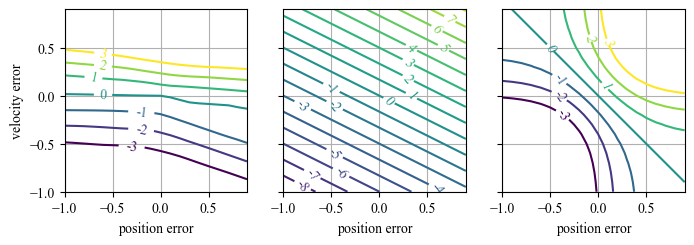

In [12]:
# visualize level sets of controller
x1 = np.arange(-1.0, 1.0, 0.1)
x2 = np.arange(-1.0, 1.0, 0.1)
X, Y = np.meshgrid(x1, x2)
Znn = np.zeros_like(X)
Zlin = np.zeros_like(X)
Znonlin = np.zeros_like(X)
k1, k2 = 3, 6
B1, g1, B2, g2 = 3, 2., 3, 1.
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        err = torch.tensor([X[i, j], Y[i, j]]).float().to(device)
        actions = nn_ctrl(err.unsqueeze(0)).detach().cpu().squeeze().item()
        Znn[i, j] = actions
        Zlin[i, j] = (k1 * err[0] + k2 * err[1])
        Znonlin[i, j] = (B1 * np.tanh(g1 * err[0]) + B2 * np.tanh(g1 * err[1]))
fig, ax = plt.subplots(1, 3, figsize=(8, 6), sharex=True, sharey=True)
cl = a_max
clevels = list(np.arange(-cl, cl, 1.)) + [cl - 1e-6]
cs0 = ax[0].contour(X, Y, Znn, levels=clevels)
cs2 = ax[2].contour(X, Y, Znonlin, levels=clevels)
clevels = list(np.arange(-10, 10.1, 1.))
cs1 = ax[1].contour(X, Y, Zlin, levels=clevels)
def fmt(x):
    s = f'{x:.0f}'
    return f"{s}"
ax[0].clabel(cs0, inline=True, fontsize=10, fmt=fmt)
ax[1].clabel(cs1, inline=True, fontsize=10, fmt=fmt)
ax[2].clabel(cs2, inline=True, fontsize=10, fmt=fmt)
ax[0].set_xlabel('position error')
ax[1].set_xlabel('position error')
ax[2].set_xlabel('position error')
ax[0].set_ylabel('velocity error')
ax[0].set_aspect(1)
ax[1].set_aspect(1)
ax[2].set_aspect(1)
for a in ax:
    a.grid()
plt.show()

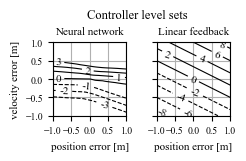

In [8]:
# visualize level sets of controller
x1 = np.arange(-1.0, 1.01, 0.05)
x2 = np.arange(-1.0, 1.01, 0.05)
X, Y = np.meshgrid(x1, x2)
Znn = np.zeros_like(X)
Zlin = np.zeros_like(X)
k1, k2 = 3, 6
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        err = torch.tensor([X[i, j], Y[i, j]]).float().to(device)
        actions = nn_ctrl(err.unsqueeze(0)).detach().cpu().squeeze().item()
        Znn[i, j] = actions
        Zlin[i, j] = (k1 * err[0] + k2 * err[1])
fig, ax = plt.subplots(1, 2, figsize=(2.5, 1.5), sharex=True, sharey=True)
fig.suptitle("Controller level sets", fontsize=title_size, x=.57)
fig.subplots_adjust(0.17, 0.27, 1., 0.76, 0., 0.2)
cl = a_max
clevels = list(np.arange(-cl, cl, 1.)) + [cl - 1e-6]
cs0 = ax[0].contour(X, Y, Znn, levels=clevels, colors='k', linewidths=linewidth)
cs1 = ax[1].contour(X, Y, Zlin, levels=np.arange(-10., 10., 2.), colors='k', linewidths=linewidth)
def fmt(x):
    s = f'{round(x)}'
    return f"{s}"
ax[0].set_title("Neural network", fontsize=subtitle_size)
ax[1].set_title("Linear feedback", fontsize=subtitle_size)
ax[0].clabel(cs0, inline=True, fontsize=subtitle_size, fmt=fmt)
ax[1].clabel(cs1, inline=True, fontsize=subtitle_size, fmt=fmt)
ax[0].set_xlabel('position error [m]', fontsize=axes_size)
ax[1].set_xlabel('position error [m]', fontsize=axes_size)
ax[0].set_ylabel('velocity error [m]', fontsize=axes_size)
ticks = [-1, -0.5, 0., 0.5, 1]
for a in ax:
    a.set_aspect(1)
    a.grid()
    a.set_xlim([-1, 1])
    a.set_ylim([-1, 1])
    a.tick_params(axis='both', labelsize=tick_label_size)
    a.set_xticks(ticks)
    a.set_yticks(ticks)
plt.show()
nn_ctrl_level_sets_save_loc = fig_save_loc + '/iros_nn_ctrl_level_sets.pdf'
fig.savefig(nn_ctrl_level_sets_save_loc, bbox_inches='tight')